In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("karakaggle/kaggle-cat-vs-dog-dataset")

print("Path to dataset files:", path)

100%|██████████| 787M/787M [00:10<00:00, 78.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/karakaggle/kaggle-cat-vs-dog-dataset/versions/1


In [ ]:
cp -r /root/.cache/kagglehub/datasets/karakaggle/kaggle-cat-vs-dog-dataset/versions/1/kagglecatsanddogs_3367a/PetImages .

In [ ]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
img = cv2.imread("PetImages/Cat/100.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
img.shape

(500, 403, 3)

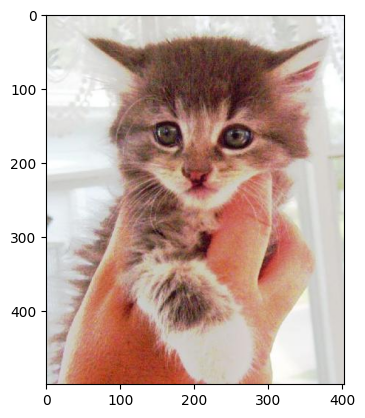

In [ ]:
plt.imshow(img)

In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import glob

In [ ]:
root_dir = "PetImages"
images_path_list = []
labels_path_list = []
for cls_idx, class_name in enumerate(["Cat", "Dog"]):
  images_tmp = os.path.join(root_dir, class_name,"*.jpg")
  images_path = glob.glob(images_tmp)
  for img_path in images_path:
    images_path_list.append(img_path)
    labels_path_list.append(cls_idx)

In [ ]:
print(images_path_list)

['PetImages/Cat/9908.jpg', 'PetImages/Cat/9589.jpg', 'PetImages/Cat/5606.jpg', 'PetImages/Cat/288.jpg', 'PetImages/Cat/8443.jpg', 'PetImages/Cat/9046.jpg', 'PetImages/Cat/2400.jpg', 'PetImages/Cat/8473.jpg', 'PetImages/Cat/6681.jpg', 'PetImages/Cat/2538.jpg', 'PetImages/Cat/184.jpg', 'PetImages/Cat/10182.jpg', 'PetImages/Cat/8018.jpg', 'PetImages/Cat/8767.jpg', 'PetImages/Cat/937.jpg', 'PetImages/Cat/11041.jpg', 'PetImages/Cat/2461.jpg', 'PetImages/Cat/1645.jpg', 'PetImages/Cat/7647.jpg', 'PetImages/Cat/8606.jpg', 'PetImages/Cat/2189.jpg', 'PetImages/Cat/11003.jpg', 'PetImages/Cat/3619.jpg', 'PetImages/Cat/12114.jpg', 'PetImages/Cat/1680.jpg', 'PetImages/Cat/4008.jpg', 'PetImages/Cat/5821.jpg', 'PetImages/Cat/5812.jpg', 'PetImages/Cat/5380.jpg', 'PetImages/Cat/3675.jpg', 'PetImages/Cat/10451.jpg', 'PetImages/Cat/10111.jpg', 'PetImages/Cat/6704.jpg', 'PetImages/Cat/4848.jpg', 'PetImages/Cat/10141.jpg', 'PetImages/Cat/9276.jpg', 'PetImages/Cat/7895.jpg', 'PetImages/Cat/1532.jpg', 'PetIma

In [ ]:
print(labels_path_list)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
class CatsVsDogsDB(Dataset):
  def __init__(self, images_path_list, labels_path_list, transform):
    self.images_path_list =  images_path_list
    self.labels_path_list =  labels_path_list
    self.transform =  transform

  def __len__(self):
    return len(self.images_path_list)

  def __getitem__(self, index):
    path = self.images_path_list[index]
    label =  self.labels_path_list[index]

    image = Image.open(path).convert("RGB")

    image = self.transform(image)

    return image, label

In [ ]:
transform = transforms.Compose(
    [
        transforms.Resize((32,32)),
      transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5],[0.5, 0.5, 0.5])
    ]
)
# Normalize:  x in X: x->(x - mean(X))/stdv(x)


In [ ]:
train_dataset = CatsVsDogsDB(images_path_list,labels_path_list, transform)

In [ ]:
train_dataset.__len__()

24959

In [ ]:
image, label = train_dataset.__getitem__(3)

In [ ]:
image.shape

torch.Size([3, 32, 32])

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class CatDogClsModel(nn.Module):
  def __init__(self, input_size=32*32, hidden_size1=256, hidden_size2=128,num_classes=2):
    super(CatDogClsModel, self).__init__()
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(input_size, hidden_size1)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size1, hidden_size2)
    self.fc3 = nn.Linear(hidden_size2, num_classes)

  def forward(self, x):
    x1 = self.flatten(x)
    x2 = self.fc1(x1)
    x3 = self.relu(x2)
    x4 = self.fc2(x3)
    x5 = self.relu(x4)
    x6 = self.fc3(x5)

    return x6


In [ ]:
train_dataset = CatsVsDogsDB(images_path_list,labels_path_list, transform)

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
train_size = int(0.8*len(train_dataset))
val_size = len(train_dataset) - train_size

In [ ]:
print(train_size)
print(val_size)

19967
4992


In [ ]:
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size = 8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size = 8, shuffle=True)

In [ ]:
mlp_model = CatDogClsModel(input_size=3*32*32)

In [ ]:
print(mlp_model)

CatDogClsModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=256, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)


In [ ]:
device =  torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
mlp_model = mlp_model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

In [ ]:
import tqdm
num_epochs = 2

In [ ]:
for epoch in range(num_epochs):
  print(f'Epoch : {epoch}')
  mlp_model.train()
  running_loss = 0.0
  for images, labels in  tqdm.tqdm(train_loader):
    images, labels = images.to(device), labels.to(device)

    outputs = mlp_model(images)

    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch {epoch}/{num_epochs}, Loss : {running_loss/len(train_loader):.4f}")

Epoch : 0


  5%|▌         | 136/2496 [00:02<00:40, 57.89it/s]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))
100%|██████████| 2496/2496 [00:48<00:00, 51.40it/s]


Epoch 0/2, Loss : 0.6627
Epoch : 1


100%|██████████| 2496/2496 [00:46<00:00, 53.65it/s]

Epoch 1/2, Loss : 0.6341


In [ ]:
mlp_model.eval()
val_loss = 0.0
correct = 0
total = 0
with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = mlp_model(images)
    loss = criterion(outputs, labels)

    val_loss += loss.item()

    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

In [ ]:
correct / total

0.640625